In [1]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.utils import plot_iv_surface, repair_edges_local_directional, jitter_grid, plot_param_error_ecdfs, plot_param_true_vs_est
from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

# cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)
# surfaces = generate_surfaces(
#     num_sets=1,
#     forward_curves_per_set=10,
#     cfg=cfg,
#     seed=4235,
#     randomize_grid=False,
# )


SAVE_ROOT = "data/new_longrun"
surfaces = []

# List and sort all batch files (batch_0000.pkl, batch_0001.pkl, ...)
batch_files = sorted([
    f for f in os.listdir(SAVE_ROOT)
    if f.startswith("batch_") and f.endswith(".pkl")
])

# print(f"Found {len(batch_files)} batch files.")

for fname in batch_files:
    path = os.path.join(SAVE_ROOT, fname)
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
            # If each file stores {"surfaces": [...]} dicts:
            if isinstance(data, dict) and "surfaces" in data:
                surfaces.extend(data["surfaces"])
            # Or if it’s already a list:
            elif isinstance(data, list):
                surfaces.extend(data)
            else:
                print(f"⚠️ Unrecognized format in {fname}")
        print(f"Loaded {fname}")
    except Exception as e:
        print(f"❌ Error loading {fname}: {e}")

print(f"\n✅ Total surfaces loaded: {len(surfaces)}")

for i in surfaces:
    x = i["iv_surface"]
    maturities = np.array(i["grid"]["maturities"])
    strikes = np.array(i["grid"]["strikes"])
    i["iv_surface"] =  repair_edges_local_directional(x, maturities, strikes)

Loaded batch_0000.pkl
Loaded batch_0001.pkl
Loaded batch_0002.pkl
Loaded batch_0003.pkl
Loaded batch_0004.pkl
Loaded batch_0005.pkl
Loaded batch_0006.pkl
Loaded batch_0007.pkl
Loaded batch_0008.pkl
Loaded batch_0009.pkl
Loaded batch_0010.pkl
Loaded batch_0011.pkl
Loaded batch_0012.pkl
Loaded batch_0013.pkl
Loaded batch_0014.pkl
Loaded batch_0015.pkl
Loaded batch_0016.pkl
Loaded batch_0017.pkl
Loaded batch_0018.pkl
Loaded batch_0019.pkl
Loaded batch_0020.pkl
Loaded batch_0021.pkl
Loaded batch_0022.pkl
Loaded batch_0023.pkl
Loaded batch_0024.pkl
Loaded batch_0025.pkl
Loaded batch_0026.pkl
Loaded batch_0027.pkl
Loaded batch_0028.pkl
Loaded batch_0029.pkl
Loaded batch_0030.pkl
Loaded batch_0031.pkl
Loaded batch_0032.pkl
Loaded batch_0033.pkl
Loaded batch_0034.pkl
Loaded batch_0035.pkl
Loaded batch_0036.pkl
Loaded batch_0037.pkl
Loaded batch_0038.pkl
Loaded batch_0039.pkl
Loaded batch_0040.pkl
Loaded batch_0041.pkl
Loaded batch_0042.pkl
Loaded batch_0043.pkl
Loaded batch_0044.pkl
Loaded bat

# Original Fixed Grid Training Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
import matplotlib.ticker as mtick
import time
f = gzip.GzipFile('TrainrBergomiTermStructure.txt.gz', "r")
dat=np.load(f)
print(dat.shape)
xx=dat[:,:11]
yy=dat[:,11:]
print(xx.shape)
strikes=np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5 ])
maturities=np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0 ])
import numpy as np

# Constants from your setup
strikes = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
maturities = np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0])

num_strikes = len(strikes)
num_maturities = len(maturities)
num_samples = len(xx)

surfaces = []

for i in range(num_samples):
    # forward vols (first 8), eta, rho, H
    fwd_vols = xx[i, :8].tolist()
    eta = float(xx[i, 8])
    rho = float(xx[i, 9])
    H   = float(xx[i, 10])

    # reshape yy row into surface (maturities × strikes)
    iv_surface = yy[i].reshape(num_maturities, num_strikes)

    # build the structured dictionary
    surfaces.append({
        "set_id": int(i),
        "fwd_id": int(i),  # or e.g. i // 100 if multiple fwd vols share params
        "params": {
            "eta": eta,
            "rho": rho,
            "H": H,
            "xi0_knots": fwd_vols
        },
        "grid": {
            "strikes": strikes.astype(np.float32),
            "maturities": maturities.astype(np.float32)
        },
        "iv_surface": iv_surface.astype(np.float32)
    })

# optional: check example
print(surfaces[0]["params"])
print(surfaces[0]["iv_surface"].shape)


(80000, 99)
(80000, 11)
{'eta': 1.09063, 'rho': -0.477665, 'H': 0.41078, 'xi0_knots': [0.0989267, 0.13664, 0.138692, 0.137088, 0.103535, 0.0676573, 0.0546302, 0.0185069]}
(8, 11)


# My Training Data

In [2]:
train_data = surfaces[:int(0.9*len(surfaces))]
test_data = surfaces[int(0.9*len(surfaces)):]

#mlp_training = train_data
#deeponet_training = train_data
# Training splits
mlp_training = [d for d in train_data if ((d["grid_id"] == 0) and (d["fwd_id"] == 0))]
deeponet_training = [d for d in train_data if ((d["grid_id"] == 1) and (d["fwd_id"] == 0))]

#Test split
test_data = [d for d in test_data if ((d["grid_id"] == 1) and (d["fwd_id"] == 0))]
len(deeponet_training)

10044

In [3]:
# ============================================================
# Usage Notes (example)
# ============================================================
#DeepONet (with internal scaling):
deeponet_model, train_loader, val_loader, Ks, Ts = DeepONet.from_surfaces(deeponet_training, mask_type="contextual", shuffle_training_batches=False,
    batch_size=8*11*11, val_split=0.2, latent_dim=64, branch_hidden_dims=(64, 64), trunk_hidden_dims=(64,64), ref_strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]), ref_maturities= np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1]))
deeponet_model.train_model(train_loader, val_loader, epochs=100, lr_schedule=[(0,0.001),(75,0.0001), (95, 0.00001)])
print("DeepONet Model param counts: ",deeponet_model.count_parameters())
# fig = model.plot_evaluation(test_surfaces[0])
deeponet_eval = deeponet_model.evaluate(test_data, out_dir="deeponet_eval")

Epoch 002 | train_rmse=0.107709, val_rmse=0.088897, lr=1.0e-03, time=15.12s, ETA=25.21 min

KeyboardInterrupt: 

In [ ]:
deeponet_cal_eval = deeponet_model.evaluate_calibrate(test_data, optimiser="levenberg-marquardt", out_dir="deeponet_eval")


Evaluating calibration using levenberg-marquardt on 1038 surfaces...

→ Final avg time: 100.4 ms, mean RMSE=0.00124

Relative Errors per Parameter:
   eta      | mean=1.951% | median=1.170% | std=2.753%
   rho      | mean=2.313% | median=1.223% | std=3.117%
   H        | mean=7.313% | median=3.831% | std=17.363%
   xi0_0    | mean=4.246% | median=1.644% | std=8.956%
   xi0_1    | mean=4.965% | median=2.447% | std=8.609%
   xi0_2    | mean=5.588% | median=2.887% | std=7.859%
   xi0_3    | mean=8.576% | median=4.056% | std=18.602%
   xi0_4    | mean=14.064% | median=6.077% | std=29.740%
   xi0_5    | mean=18.305% | median=8.690% | std=30.744%
   xi0_6    | mean=23.084% | median=10.959% | std=38.796%
   xi0_7    | mean=26.309% | median=11.522% | std=50.827%

Absolute Errors per Parameter:
   eta      | mean=0.036 | median=0.023 | std=0.040 | RMSE=0.053
   rho      | mean=0.011 | median=0.006 | std=0.019 | RMSE=0.022
   H        | mean=0.013 | median=0.009 | std=0.014 | RMSE=0.019
   xi0_

In [39]:
# MLP (with internal scaling):
mlp_model, train_loader, val_loader, Ks, Ts = MLP.from_surfaces(mlp_training,
    batch_size=8, val_split=0.2, hidden_dims=(80,80,80,80))
mlp_model.train_model(train_loader, val_loader, epochs=100, lr_schedule=[(0,0.001),(75,0.0001), (95, 0.00001)])
print("MLP Model param counts: ",mlp_model.count_parameters())
#fig = model.plot_evaluation(test_surfaces[0])
mlp_eval = mlp_model.evaluate(test_data, out_dir="mlp_eval")

Epoch 001 | train_rmse=0.446175, val_rmse=0.194170, lr=1.0e-03, time=1.62s, ETA=2.68 min


Epoch 002 | train_rmse=0.151587, val_rmse=0.118711, lr=1.0e-03, time=1.67s, ETA=2.69 min


Epoch 003 | train_rmse=0.106023, val_rmse=0.092166, lr=1.0e-03, time=1.56s, ETA=2.61 min


Epoch 004 | train_rmse=0.091589, val_rmse=0.094212, lr=1.0e-03, time=1.67s, ETA=2.61 min


Epoch 005 | train_rmse=0.082530, val_rmse=0.075427, lr=1.0e-03, time=1.76s, ETA=2.62 min


...

Epoch 096 | train_rmse=0.033711, val_rmse=0.036676, lr=1.0e-05, time=1.70s, ETA=0.11 min


Epoch 097 | train_rmse=0.033605, val_rmse=0.036609, lr=1.0e-05, time=1.71s, ETA=0.08 min


Epoch 098 | train_rmse=0.033591, val_rmse=0.036638, lr=1.0e-05, time=1.60s, ETA=0.05 min


Epoch 099 | train_rmse=0.033579, val_rmse=0.036661, lr=1.0e-05, time=1.44s, ETA=0.03 min


Epoch 100 | train_rmse=0.033586, val_rmse=0.036613, lr=1.0e-05, time=1.53s, ETA=0.00 min

✅ Training completed in 2.71 min (avg 1.63s per epoch)
Model exported to exports\mlp_final.json
MLP Model param counts:  30201


In [40]:
mlp_cal_eval = mlp_model.evaluate_calibrate(test_data, optimiser="levenberg-marquardt", out_dir="mlp_eval")



Evaluating calibration using levenberg-marquardt on 1038 surfaces...

→ Final avg time: 86.4 ms, mean RMSE=0.00148

Relative Errors per Parameter:
   eta      | mean=2.216% | median=1.267% | std=3.195%
   rho      | mean=2.485% | median=1.365% | std=3.287%
   H        | mean=8.842% | median=4.630% | std=22.112%
   xi0_0    | mean=10.037% | median=2.578% | std=23.237%
   xi0_1    | mean=12.500% | median=5.855% | std=19.311%
   xi0_2    | mean=12.300% | median=5.684% | std=26.577%
   xi0_3    | mean=13.351% | median=5.924% | std=39.182%
   xi0_4    | mean=13.039% | median=6.525% | std=25.104%
   xi0_5    | mean=16.273% | median=7.429% | std=28.814%
   xi0_6    | mean=18.581% | median=8.563% | std=36.382%
   xi0_7    | mean=24.963% | median=9.041% | std=61.043%

Absolute Errors per Parameter:
   eta      | mean=0.040 | median=0.027 | std=0.041 | RMSE=0.058
   rho      | mean=0.013 | median=0.006 | std=0.021 | RMSE=0.025
   H        | mean=0.017 | median=0.010 | std=0.021 | RMSE=0.027
   

In [41]:
from generation.utils import  plot_param_error_ecdfs, plot_param_true_vs_est, compare_model_robustness
import matplotlib.pyplot as plt
plot_param_true_vs_est(
    results=[deeponet_cal_eval, mlp_cal_eval],
    labels=["DeepONet", "MLP"],
    out_dir="comparison_plots"
)

plot_param_error_ecdfs(
    [deeponet_cal_eval, mlp_cal_eval],
    ["DeepONet", "MLP"],
    out_dir="comparison_plots",
    kind="relative"
)

plot_param_error_ecdfs(
    [deeponet_cal_eval, mlp_cal_eval],
    ["DeepONet", "MLP"],
    out_dir="comparison_plots",
    kind="absolute"
)

Saved scatter comparison to comparison_plots\param_true_vs_est.png
Saved relative error ECDF comparison to comparison_plots\param_error_cdfs_relative.png
Saved RMSE ECDF comparison to comparison_plots\rmse_ecdf.png
Saved absolute error ECDF comparison to comparison_plots\param_error_cdfs_absolute.png
Saved RMSE ECDF comparison to comparison_plots\rmse_ecdf.png


In [47]:
stats = compare_model_robustness(
    models=[mlp_model, deeponet_model],
    model_labels=["MLP", "DeepONet"],
    surfaces=test_data[:100],
    noise_levels=[0,0.001, 0.0025, 0.005 ,0.0075, 0.01],
    n_real=1,
    out_dir="robustness_comparison"
)

Saved comparison plot to robustness_comparison\robustness_comparison.png


# Consistency check 


=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   3.902 s
dB computation        :   1.771 s
Y computation (fBM)   :   2.261 s
TOTAL setup           :   7.934 s

=== Diagnostics for seed 400 ===
Simulator setup:       7.975 s
Xi0 mapping:           0.003 s
Path generation:       2.419 s
CMC integrals:         0.819 s
IV extraction total:   0.677 s (of which Brent inversions ≈   0.196 s)
TOTAL runtime:        11.893 s

=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   3.107 s
dB computation        :   0.305 s
Y computation (fBM)   :   1.959 s
TOTAL setup           :   5.371 s

=== Diagnostics for seed 400 ===
Simulator setup:       5.372 s
Xi0 mapping:           0.000 s
Path generation:       4.603 s
CMC integrals:         2.214 s
IV extraction total:   0.651 s (of which Brent inversions ≈   0.140 s)
TOTAL runtime:        12.839 s

=== S

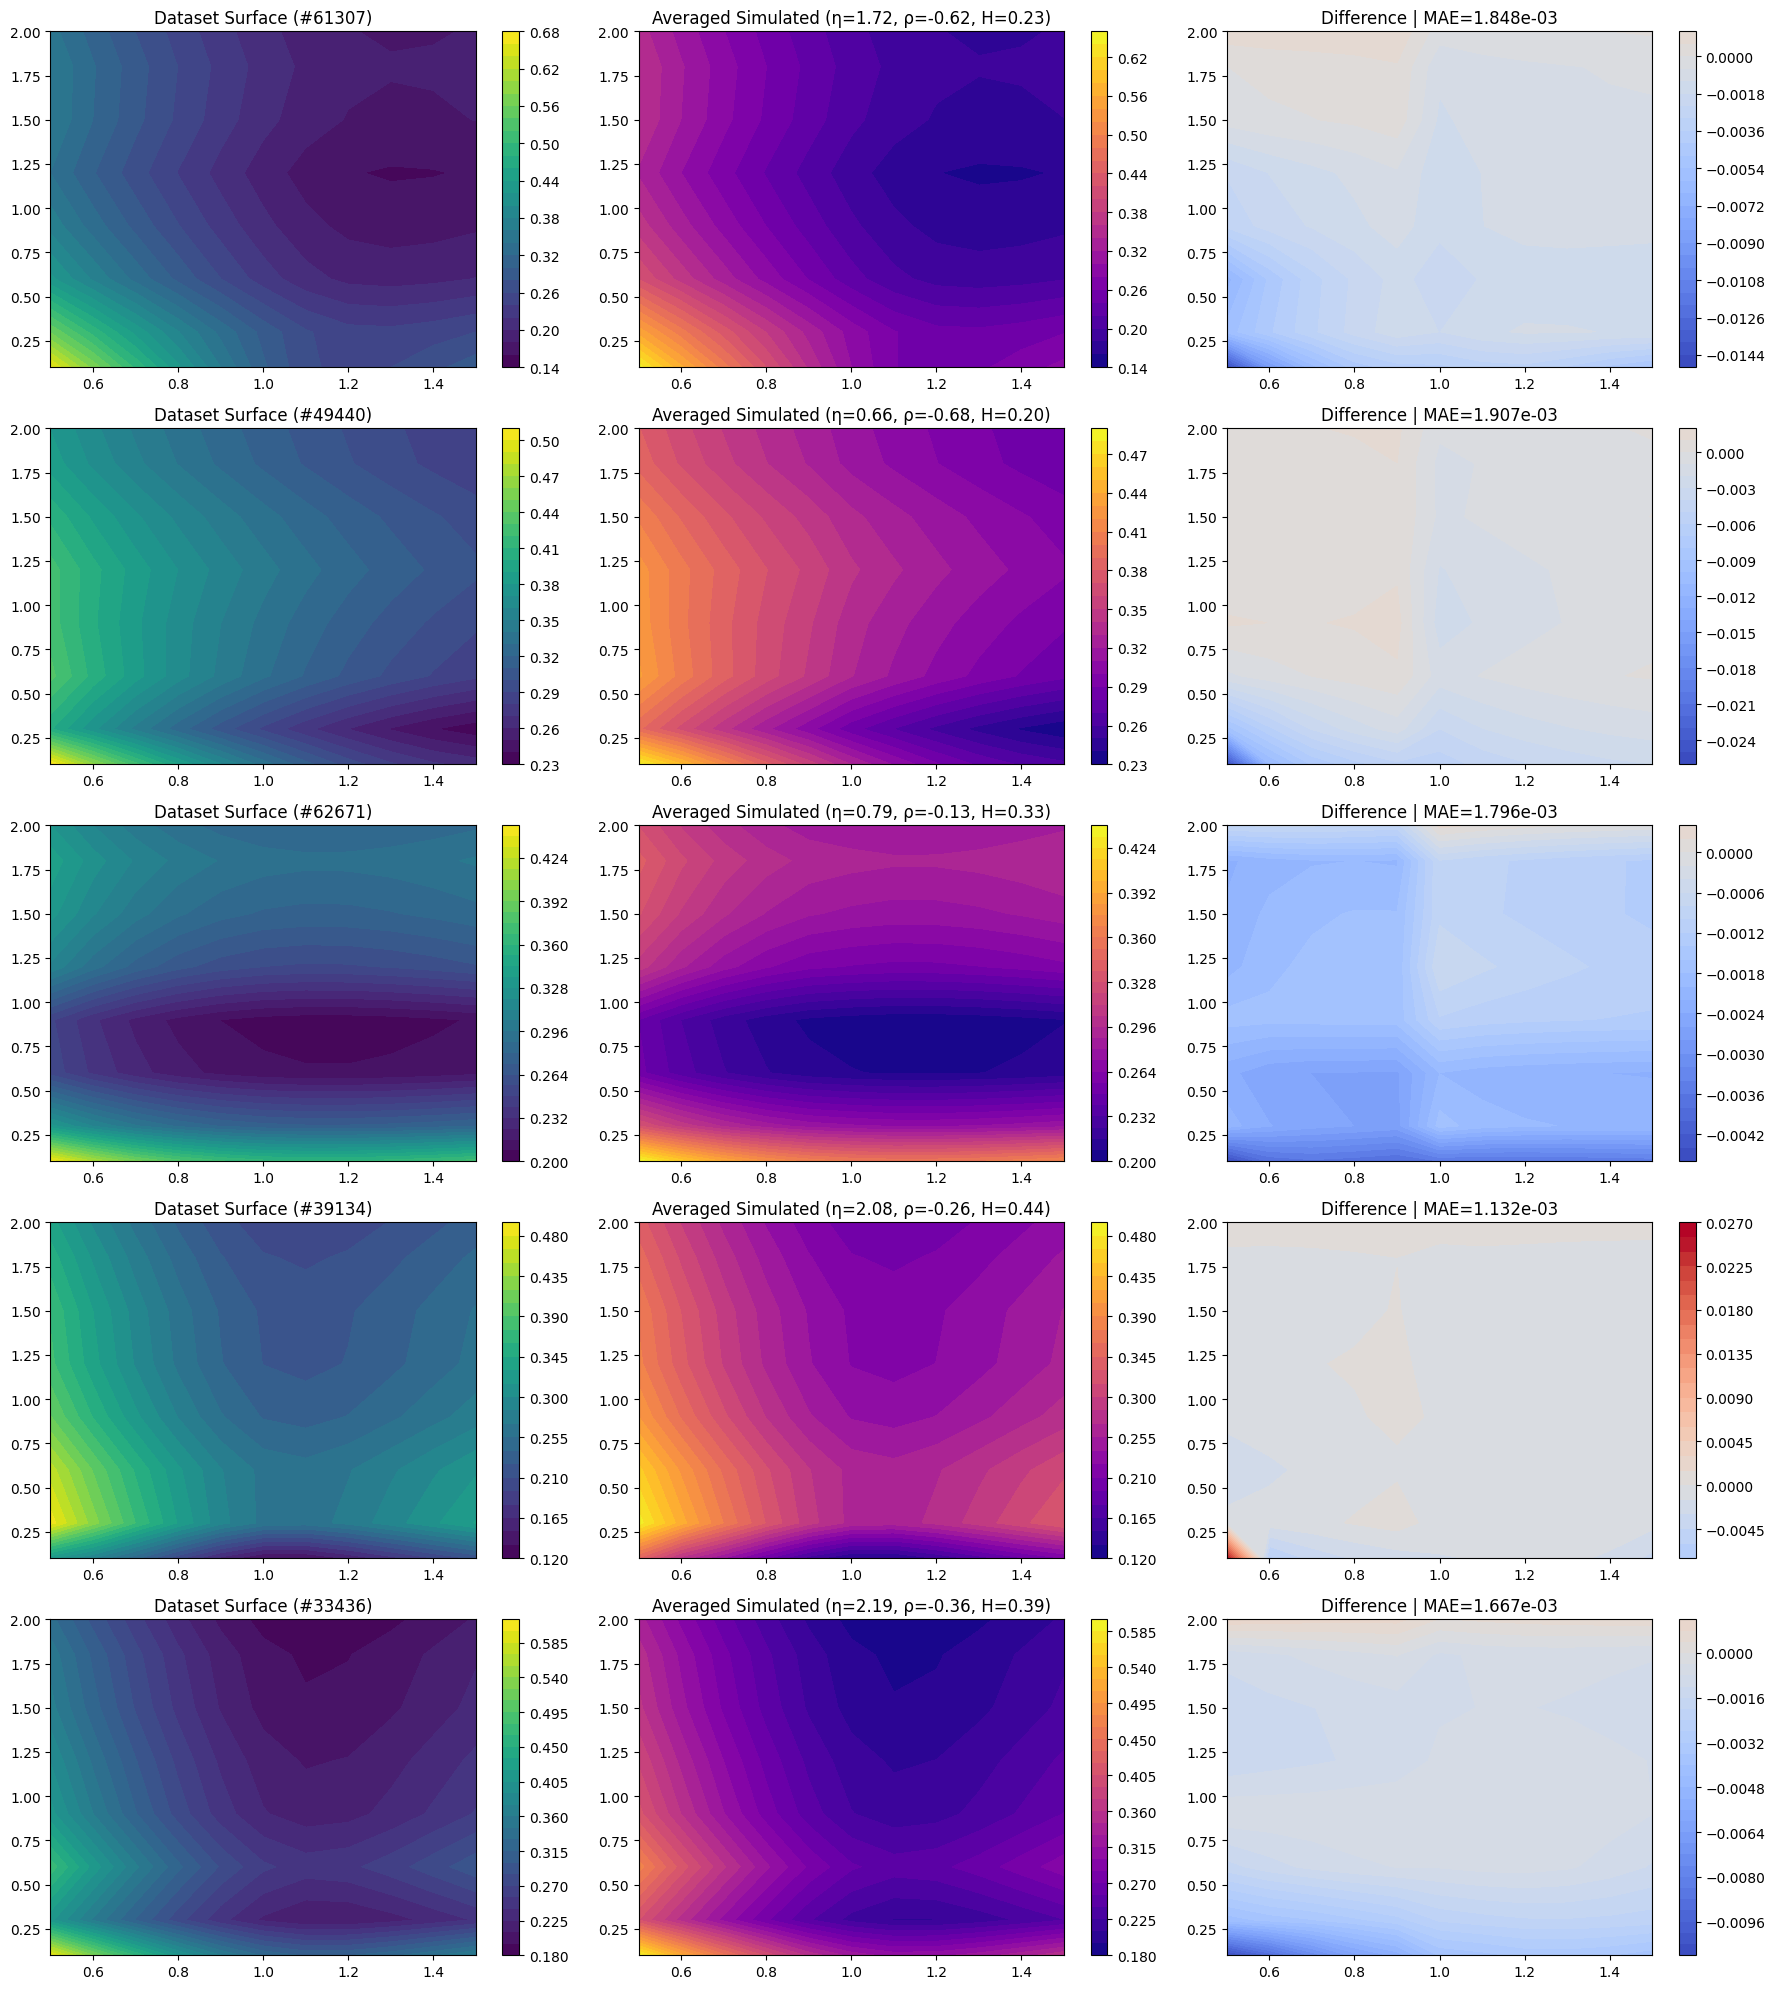

Comparison summary (averaged over seeds):
Idx 61307 | η=1.718, ρ=-0.624, H=0.231 | MAE=1.848e-03
Idx 49440 | η=0.663, ρ=-0.679, H=0.201 | MAE=1.907e-03
Idx 62671 | η=0.786, ρ=-0.134, H=0.325 | MAE=1.796e-03
Idx 39134 | η=2.077, ρ=-0.260, H=0.444 | MAE=1.132e-03
Idx 33436 | η=2.191, ρ=-0.363, H=0.395 | MAE=1.667e-03


In [12]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 5        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(123789)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


In [ ]:
K = np.linspace(0.5, 1.5, 30)
T = np.linspace(0.05, 2.0, 30)
K_mesh, T_mesh = np.meshgrid(K, T)
grid = np.stack([K_mesh.ravel(), T_mesh.ravel()], axis=1)

xb_sample = np.array([2.0, -0.3, 0.1, 0.1, 0.1, 0.1, 0.1,0.1,0.1,0.1,0.1])
mask = deeponet_model.test_mask_response(xb_sample, grid)

In [ ]:
k = 62000
x = surfaces[k]["iv_surface"]
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])
strikes = np.array(surfaces[k]["grid"]["strikes"])
# --- reconstruct bin edges for piecewise-constant ξ₀(t) ---
# first edge starts at 0, last one ends at the final maturity
edges = np.concatenate([[0.0], maturities])
plot_iv_surface(
    x, strikes, maturities,
    xi0_knots=xi0_knots,      # K values
    xi0_bin_edges=edges,      # K+1 edges
)